LAB 2: XỬ LÝ ẢNH CƠ BẢN VỚI NUMPY
LAB 2 gồm 5 phần chính:
1. Chuyển đổi màu sắc (RGB -> HSV, RGB -> HSL)
2. Blending (pha trộn) ảnh
3. Thresholding (phân ngưỡng) - 6 loại
4. Blurring & Smoothing (làm mờ) - 4 loại
5. Histogram Equalization (cân bằng histogram)





#1. Конвертация между цветовыми пространствами
*   RGB -> HSV
*   RGB -> HSL



In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import requests
from PIL import Image
from io import BytesIO
import urllib.parse
%matplotlib inline

def rgb_to_hsv(rgb_image):
    """RGB -> HSV"""
    # Lưu shape và reshape
    original_shape = rgb_image.shape
    if len(original_shape) == 3:
        rgb_flat = rgb_image.reshape(-1, 3).astype(float) / 255.0
    else:
        rgb_flat = rgb_image.astype(float) / 255.0

    r, g, b = rgb_flat[:, 0], rgb_flat[:, 1], rgb_flat[:, 2]

    # Tính max, min
    cmax = np.maximum(np.maximum(r, g), b)
    cmin = np.minimum(np.minimum(r, g), b)
    delta = cmax - cmin

    # Value
    v = cmax

    # Saturation
    s = np.zeros_like(cmax)
    mask = cmax != 0
    s[mask] = delta[mask] / cmax[mask]

    # Hue
    h = np.zeros_like(cmax)

    # Xử lý các trường hợp
    mask_delta = delta != 0

     # Trường hợp Red là max
    mask_r = (cmax == r) & mask_delta
    h[mask_r] = 60 * ((g[mask_r] - b[mask_r]) / delta[mask_r] % 6)

     # Trường hợp Green là max
    mask_g = (cmax == g) & mask_delta
    h[mask_g] = 60 * ((b[mask_g] - r[mask_g]) / delta[mask_g] + 2)

     # Trường hợp Blue là max
    mask_b = (cmax == b) & mask_delta
    h[mask_b] = 60 * ((r[mask_b] - g[mask_b]) / delta[mask_b] + 4)

    # Gray case (delta = 0)
    h[delta == 0] = 0

    # Reshape về original shape
    hsv = np.stack([h, s, v], axis=-1)
    return hsv.reshape(original_shape)

def rgb_to_hsl(rgb_image):
    """RGB -> HSL"""
    original_shape = rgb_image.shape
    if len(original_shape) == 3:
        rgb_flat = rgb_image.reshape(-1, 3).astype(float) / 255.0
    else:
        rgb_flat = rgb_image.astype(float) / 255.0

    r, g, b = rgb_flat[:, 0], rgb_flat[:, 1], rgb_flat[:, 2]

    # Tính max, min
    cmax = np.maximum(np.maximum(r, g), b)
    cmin = np.minimum(np.minimum(r, g), b)
    delta = cmax - cmin

    # Lightness
    l = (cmax + cmin) / 2.0

    # Saturation
    s = np.zeros_like(l)
    mask = delta != 0
    s[mask] = delta[mask] / (1 - np.abs(2 * l[mask] - 1))

    # Hue
    h = np.zeros_like(l)

    mask_delta = delta != 0

    # R max
    mask_r = (cmax == r) & mask_delta
    h[mask_r] = 60 * ((g[mask_r] - b[mask_r]) / delta[mask_r] % 6)

    # G max
    mask_g = (cmax == g) & mask_delta
    h[mask_g] = 60 * ((b[mask_g] - r[mask_g]) / delta[mask_g] + 2)

    # B max
    mask_b = (cmax == b) & mask_delta
    h[mask_b] = 60 * ((r[mask_b] - g[mask_b]) / delta[mask_b] + 4)

    # Gray case
    h[delta == 0] = 0

    hsl = np.stack([h, s, l], axis=-1)
    return hsl.reshape(original_shape)

def compare_conversion(image_path):
    """So sánh kết quả tự viết vs OPenCV"""
    # Kiểm tra file tồn tại
    if not os.path.exists(image_path):
        print(f"Error: File '{image_path}' not found!")
        return None, None

    # Đọc ảnh
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"Error: Cannot read image '{image_path}'!")
        return None, None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    print("Read image successfully.")

    # My implementations
    print("RGB -> HSV (my implementation)...")
    my_hsv = rgb_to_hsv(img_rgb)
    print("RGB -> HSL (my implementation)...")
    my_hsl = rgb_to_hsl(img_rgb)

    # OpenCV
    print("RGB -> HSV (OpenCV)...")
    cv_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    print("RGB -> HSL (OpenCV)...")
    cv_hls = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HLS)

    # Scale để so sánh (OpenCV dùng scale khác)
    my_hsv_scaled = my_hsv.copy()
    my_hsv_scaled[:, :, 0] = my_hsv_scaled[:, :, 0] / 2  # 360 -> 180
    my_hsv_scaled[:, :, 1:] = my_hsv_scaled[:, :, 1:] * 255  # 0-1 -> 0-255

    my_hsl_scaled = my_hsl.copy()
    my_hsl_scaled[:, :, 0] = my_hsl_scaled[:, :, 0] / 2  # 360 -> 180
    my_hsl_scaled[:, :, 1:] = my_hsl_scaled[:, :, 1:] * 255


     # Hiển thị kết quả
    print("Results:")
    plt.figure(figsize=(15, 12))

    # HSV comparison
    plt.subplot(2, 3, 1)
    plt.imshow(img_rgb)
    plt.title('Original RGB')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(my_hsv[:, :, 0], cmap='hsv', vmin=0, vmax=360)
    plt.title('My HSV - Hue (0-360°)')
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(cv_hsv[:, :, 0], cmap='hsv')
    plt.title('OpenCV HSV - Hue (0-180)')
    plt.axis('off')

    # HSL comparison
    plt.subplot(2, 3, 4)
    plt.imshow(my_hsl[:, :, 2], cmap='gray')
    plt.title('My HSL - Lightness')
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(cv_hls[:, :, 1], cmap='gray')
    plt.title('OpenCV HLS - Lightness')
    plt.axis('off')

    # Difference
    diff = np.abs(my_hsv_scaled - cv_hsv).mean(axis=2)
    plt.subplot(2, 3, 6)
    plt.imshow(diff, cmap='hot')
    plt.title(f'HSV Difference\n(Mean Error = {diff.mean():.2f})')
    plt.axis('off')

    plt.suptitle('Comparison: My Implementation vs OpenCV',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"   Mean difference (HSV): {diff.mean():.4f}")

    plt.tight_layout()
    plt.show()

    return my_hsv, my_hsl

   - Sử dụng nhiều ảnh từ Internet
   - So sánh kết quả với OpenCV
   - Hiển thị kết quả cho từng ảnh

 Chọn chế độ chạy:
   1. Demo với nhiều ảnh)
   2. Demo với 1 ảnh

Chọn chế độ (1/2): 1

Sử dụng 5 ảnh mẫu từ Pinterest:
   1. Red Apple
   2. Blue Sky
   3. Green Leaf
   4. Cute Dog
   5. Landscape

[1/5] Đang xử lý: Red Apple
Upload succesful from URL: https://i.pinimg.com/736x/81/65/e6/8165e68bd065f6c...
Shape: (736, 736, 3)

Processing: Red Apple
    RGB -> HSV (my implementation)...
   RGB -> HSL (my implementation)...
   RGB -> HSV (OpenCV)...
   RGB -> HSL (OpenCV)...


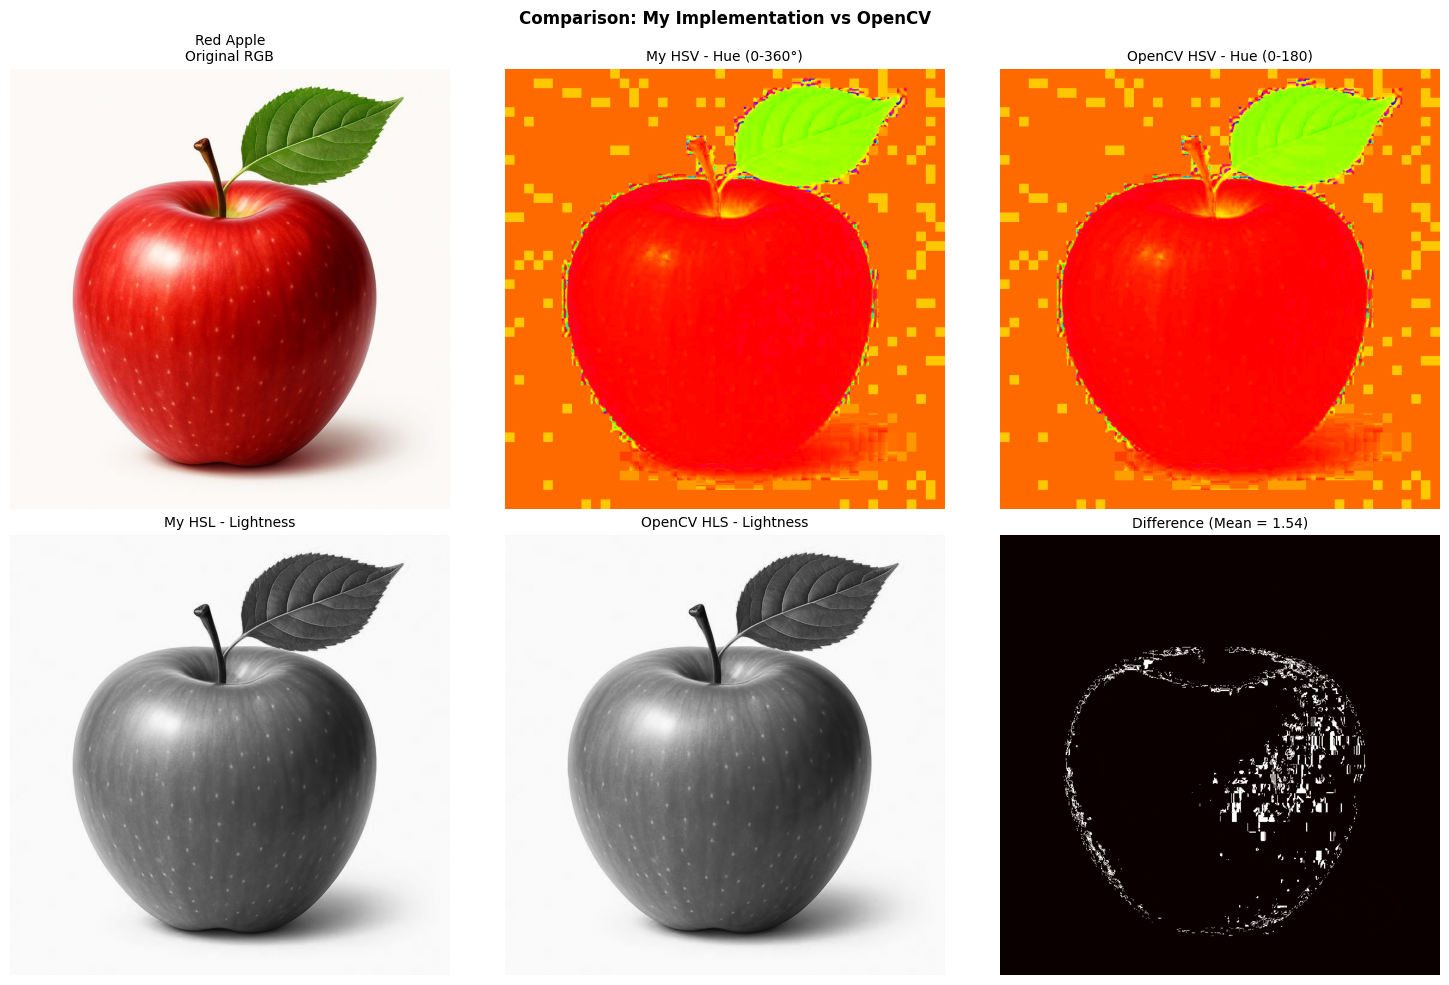

   Mean difference (HSV): 1.5417

[2/5] Đang xử lý: Blue Sky
Upload succesful from URL: https://i.pinimg.com/1200x/03/82/69/03826987245957...
Shape: (799, 1200, 3)

Processing: Blue Sky
    RGB -> HSV (my implementation)...
   RGB -> HSL (my implementation)...
   RGB -> HSV (OpenCV)...
   RGB -> HSL (OpenCV)...


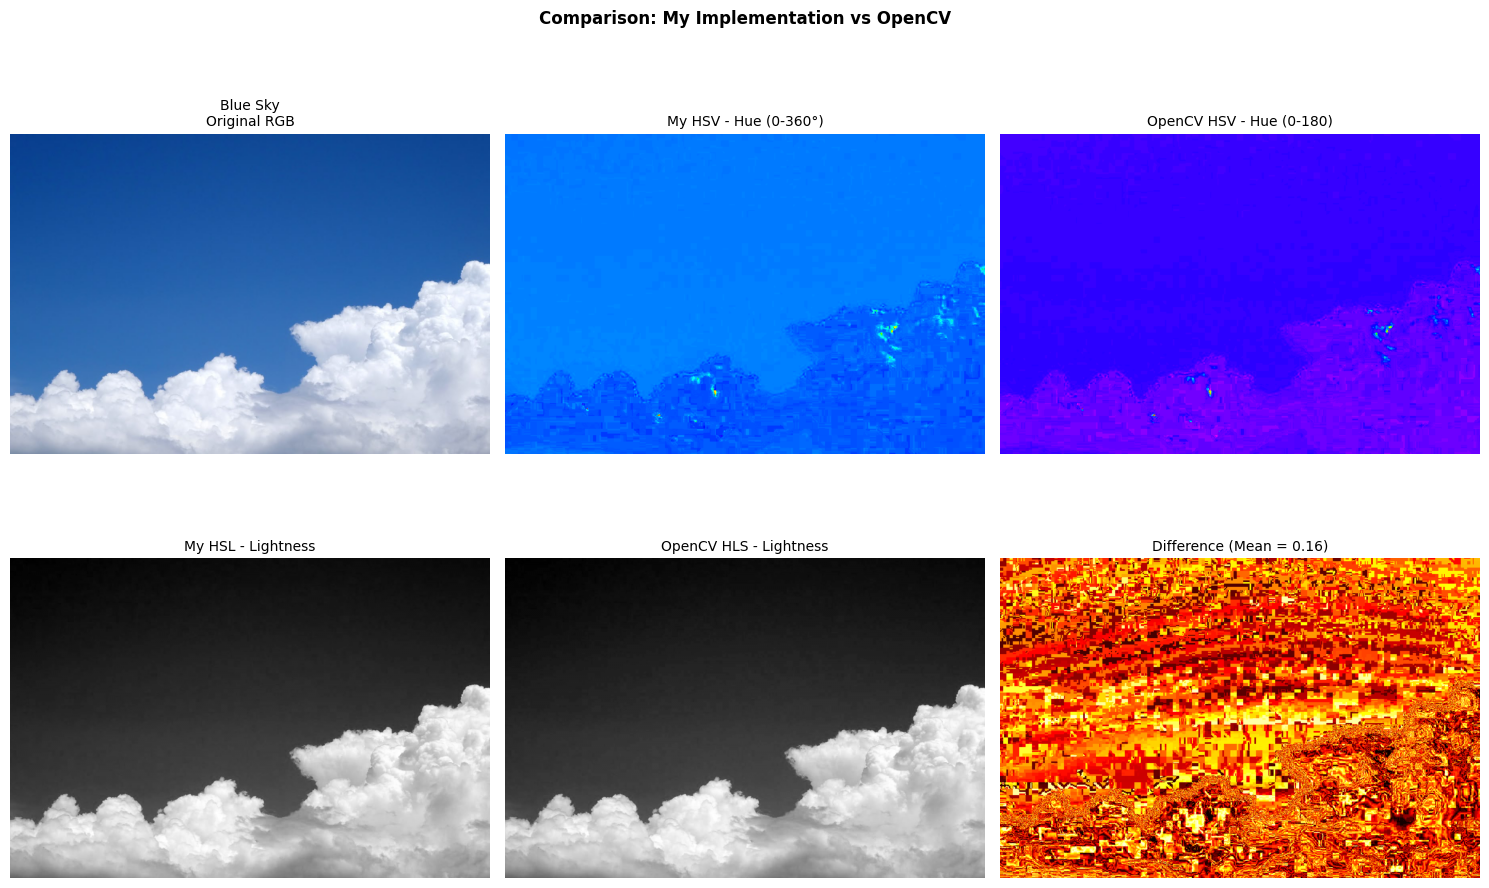

   Mean difference (HSV): 0.1555

[3/5] Đang xử lý: Green Leaf
Upload succesful from URL: https://i.pinimg.com/736x/c8/31/9c/c8319c47acce6ce...
Shape: (1280, 720, 3)

Processing: Green Leaf
    RGB -> HSV (my implementation)...
   RGB -> HSL (my implementation)...
   RGB -> HSV (OpenCV)...
   RGB -> HSL (OpenCV)...


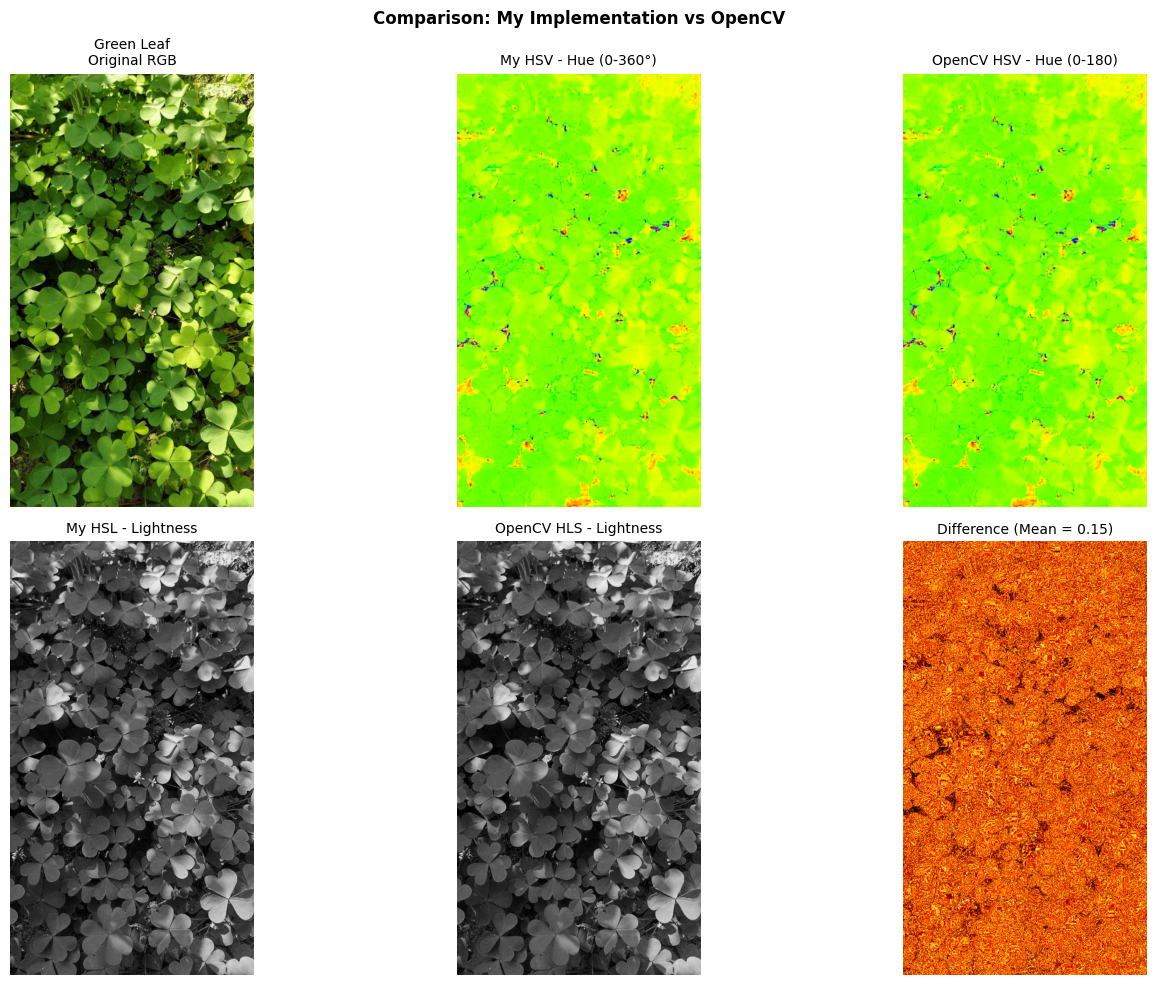

   Mean difference (HSV): 0.1548

[4/5] Đang xử lý: Cute Dog
Upload succesful from URL: https://i.pinimg.com/1200x/5f/2b/94/5f2b9485bccaa4...
Shape: (2639, 1080, 3)

Processing: Cute Dog
    RGB -> HSV (my implementation)...
   RGB -> HSL (my implementation)...
   RGB -> HSV (OpenCV)...
   RGB -> HSL (OpenCV)...


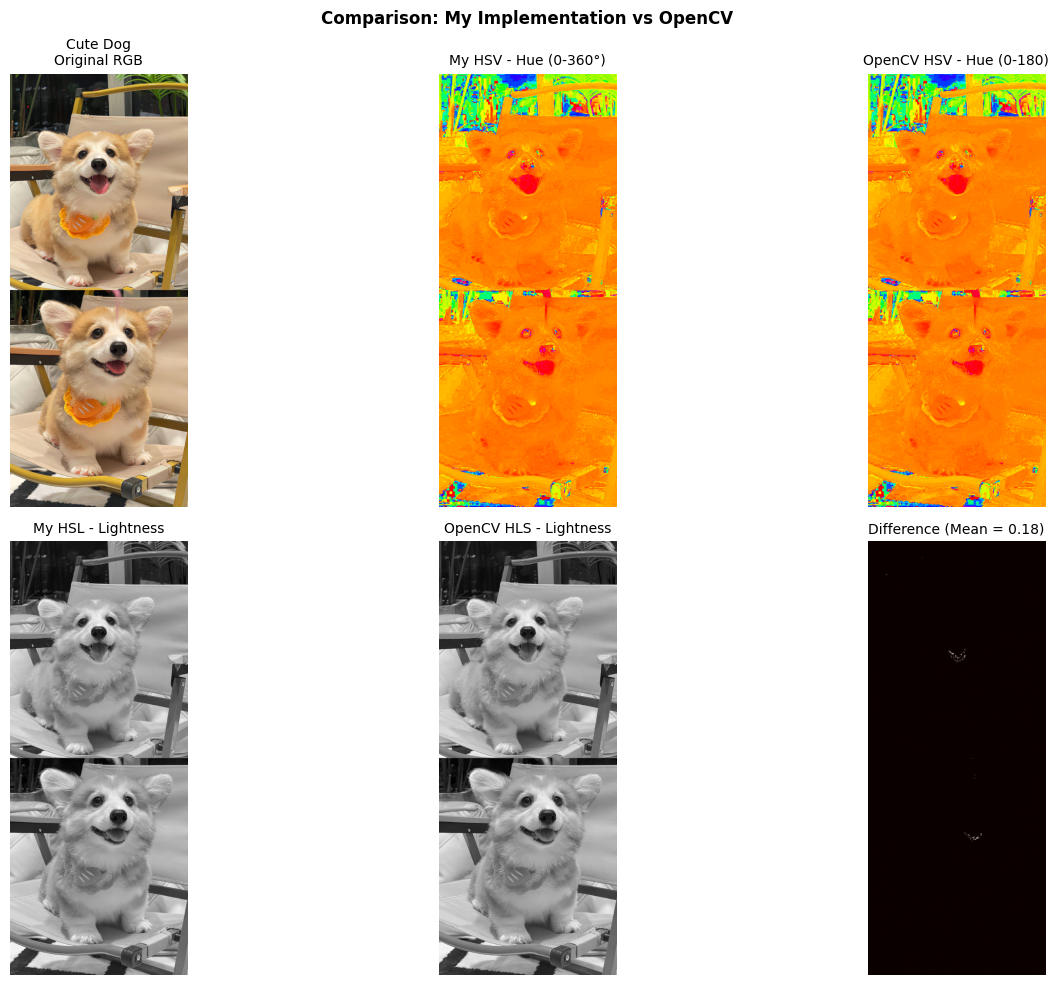

   Mean difference (HSV): 0.1772

[5/5] Đang xử lý: Landscape
Upload succesful from URL: https://i.pinimg.com/736x/97/97/7b/97977b5b33c9989...
Shape: (414, 736, 3)

Processing: Landscape
    RGB -> HSV (my implementation)...
   RGB -> HSL (my implementation)...
   RGB -> HSV (OpenCV)...
   RGB -> HSL (OpenCV)...


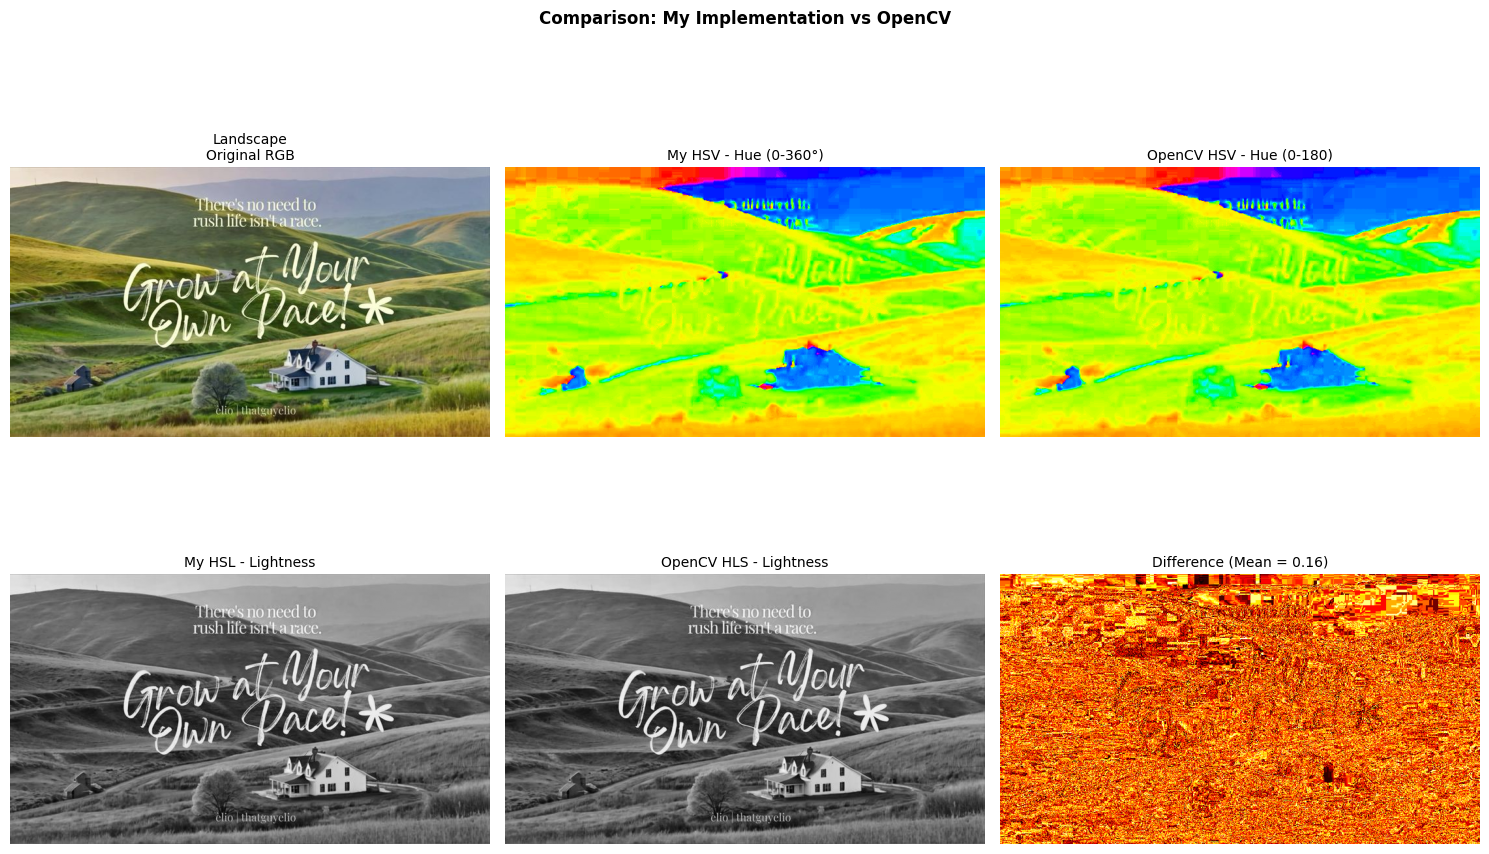

   Mean difference (HSV): 0.1621


In [7]:
# Demo functions

def load_image_from_url(url):
    """Tải ảnh từ URL"""
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content))

        # Chuyển sang numpy array
        img_np = np.array(img)

        # Nếu là ảnh RGBA, chuyển sang RGB
        if len(img_np.shape) == 3 and img_np.shape[2] == 4:
            img_np = cv2.cvtColor(img_np, cv2.COLOR_RGBA2RGB)

        # Nếu là ảnh grayscale, chuyển sang RGB
        if len(img_np.shape) == 2:
            img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)

        print(f"Upload succesful from URL: {url[:50]}...")
        print(f"Shape: {img_np.shape}")
        return img_np, True

    except Exception as e:
        print(f"Error: {e}")
        return None, False


def load_image_from_file(filepath):
    """Upload from file local"""
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None, False

    img = cv2.imread(filepath)
    if img is None:
        print(f"Can't read file: {filepath}")
        return None, False

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print(f"Read file successfully: {filepath}")
    print(f"Shape: {img_rgb.shape}")
    return img_rgb, True


def compare_conversion_from_data(img_data, image_name="Image"):
    """So sánh kết quả từ dữ liệu ảnh (không cần đọc lại file)"""

    if img_data is None:
        print(f"No data for {image_name}")
        return None, None

    img_rgb = img_data
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

    print(f"\nProcessing: {image_name}")

    # My implementations
    print("    RGB -> HSV (my implementation)...")
    my_hsv = rgb_to_hsv(img_rgb)

    print("   RGB -> HSL (my implementation)...")
    my_hsl = rgb_to_hsl(img_rgb)

    # OpenCV
    print("   RGB -> HSV (OpenCV)...")
    cv_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    print("   RGB -> HSL (OpenCV)...")
    cv_hls = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HLS)

    # Scale để so sánh (OpenCV dùng scale khác)
    my_hsv_scaled = my_hsv.copy()
    my_hsv_scaled[:, :, 0] = my_hsv_scaled[:, :, 0] / 2  # 360 -> 180
    my_hsv_scaled[:, :, 1:] = my_hsv_scaled[:, :, 1:] * 255  # 0-1 -> 0-255

    my_hsl_scaled = my_hsl.copy()
    my_hsl_scaled[:, :, 0] = my_hsl_scaled[:, :, 0] / 2  # 360 -> 180
    my_hsl_scaled[:, :, 1:] = my_hsl_scaled[:, :, 1:] * 255

    # Hiển thị kết quả
    plt.figure(figsize=(15, 10))

    # HSV comparison
    plt.subplot(2, 3, 1)
    plt.imshow(img_rgb)
    plt.title(f'{image_name}\nOriginal RGB', fontsize=10)
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(my_hsv[:, :, 0], cmap='hsv', vmin=0, vmax=360)
    plt.title('My HSV - Hue (0-360°)', fontsize=10)
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(cv_hsv[:, :, 0], cmap='hsv')
    plt.title('OpenCV HSV - Hue (0-180)', fontsize=10)
    plt.axis('off')

    # HSL comparison
    plt.subplot(2, 3, 4)
    plt.imshow(my_hsl[:, :, 2], cmap='gray')
    plt.title('My HSL - Lightness', fontsize=10)
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(cv_hls[:, :, 1], cmap='gray')
    plt.title('OpenCV HLS - Lightness', fontsize=10)
    plt.axis('off')

    # Difference
    diff = np.abs(my_hsv_scaled - cv_hsv).mean(axis=2)
    plt.subplot(2, 3, 6)
    plt.imshow(diff, cmap='hot')
    plt.title(f'Difference (Mean = {diff.mean():.2f})', fontsize=10)
    plt.axis('off')

    plt.suptitle('Comparison: My Implementation vs OpenCV', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"   Mean difference (HSV): {diff.mean():.4f}")

    return my_hsv, my_hsl


def demo_with_sample_image():
    """Demo với ảnh mẫu - chỉ 1 ảnh"""

    source = input("URL or file: ").strip()

    # Kiểm tra là URL hay file path
    if source.startswith('http://') or source.startswith('https://'):
        img_data, success = load_image_from_url(source)
        name = "Image from URL"
    else:
        img_data, success = load_image_from_file(source)
        name = os.path.basename(source) if source else "Local Image"

    if success:
        hsv, hsl = compare_conversion_from_data(img_data, name)
        return hsv, hsl
    else:
        print("Can't upload img")
        return None, None


def demo_with_multiple_images():
    """Demo với nhiều ảnh - THEO YÊU CẦU LAB"""

    # Danh sách ảnh mẫu
    sample_images = [
        {"name": "Red Apple", "url": "https://i.pinimg.com/736x/81/65/e6/8165e68bd065f6c1d32456586c08d119.jpg"},
        {"name": "Blue Sky", "url": "https://i.pinimg.com/1200x/03/82/69/03826987245957ebf0fb59ab84331086.jpg"},
        {"name": "Green Leaf", "url": "https://i.pinimg.com/736x/c8/31/9c/c8319c47acce6ce97742750c4f995faa.jpg"},
        {"name": "Cute Dog", "url": "https://i.pinimg.com/1200x/5f/2b/94/5f2b9485bccaa403f33df516d389fc92.jpg"},
        {"name": "Landscape", "url": "https://i.pinimg.com/736x/97/97/7b/97977b5b33c99892601ece8fc8073ef0.jpg"}
    ]

    print("\nSử dụng 5 ảnh mẫu từ Pinterest:")
    for i, img_info in enumerate(sample_images, 1):
        print(f"   {i}. {img_info['name']}")

    results = []

    for i, img_info in enumerate(sample_images):
        print(f"\n{'='*50}")
        print(f"[{i+1}/{len(sample_images)}] Đang xử lý: {img_info['name']}")
        print(f"{'='*50}")

        img_data, success = load_image_from_url(img_info['url'])

        if success:
            hsv, hsl = compare_conversion_from_data(img_data, img_info['name'])
            results.append((img_info['name'], hsv, hsl))
        else:
            print(f"Skip this img")
    return results


# Chạy demo
if __name__ == "__main__":
    print("   - Sử dụng nhiều ảnh từ Internet")
    print("   - So sánh kết quả với OpenCV")
    print("   - Hiển thị kết quả cho từng ảnh\n")

    print(" Chọn chế độ chạy:")
    print("   1. Demo với nhiều ảnh)")
    print("   2. Demo với 1 ảnh")

    choice = input("\nChọn chế độ (1/2): ").strip()

    if choice == "1":
        results = demo_with_multiple_images()
    elif choice == "2":
        hsv_result, hsl_result = demo_with_sample_image()
    else:
        print("Choice is unvalid, default to mode 1 with multi img")
        results = demo_with_multiple_images()


#2. Blending
Công thức blending
Kết quả = α * ảnh1 + β * ảnh2 + γ



In [35]:
def blend_images(img1, img2, alpha=0.5, beta=0.5, gamma=0):
    """
    Pha trộn 2 ảnh: result = alpha*img1 + beta*img2 + gamma
    Args:
        img1, img2: 2 ảnh cùng kích thước
        alpha: hệ số cho ảnh 1
        beta: hệ số cho ảnh 2
        gamma: độ sáng thêm vào
    """

    # Resize ảnh 2 về cùng kích thước với ảnh 1
    if img1.shape[:2] != img2.shape[:2]:
         print(f" Kích thước không khớp: {img1.shape[:2]} vs {img2.shape[:2]}")
         print(f"  Đang resize ảnh 2 về {img1.shape[1]}x{img1.shape[0]}...")
         img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    # Đảm bảo cùng kiểu dữ liệu
    img1 = img1.astype(float)
    img2 = img2.astype(float)

    # Công thức blending
    result = alpha * img1 + beta * img2 + gamma

    # Clip về [0, 255]
    result = np.clip(result, 0, 255).astype(np.uint8)

    return result, img2  # Trả về cả ảnh đã resize



URL or file img1:
→ https://i.pinimg.com/1200x/5f/2b/94/5f2b9485bccaa403f33df516d389fc92.jpg

URL or file img2:
→ https://i.pinimg.com/1200x/03/82/69/03826987245957ebf0fb59ab84331086.jpg
Upload succesful from URL: https://i.pinimg.com/1200x/5f/2b/94/5f2b9485bccaa4...
Shape: (2639, 1080, 3)
Upload succesful from URL: https://i.pinimg.com/1200x/03/82/69/03826987245957...
Shape: (799, 1200, 3)

Upload successful

Đang resize ảnh 2 từ (799, 1200) về (2639, 1080)...
  Sau resize: (2639, 1080, 3)


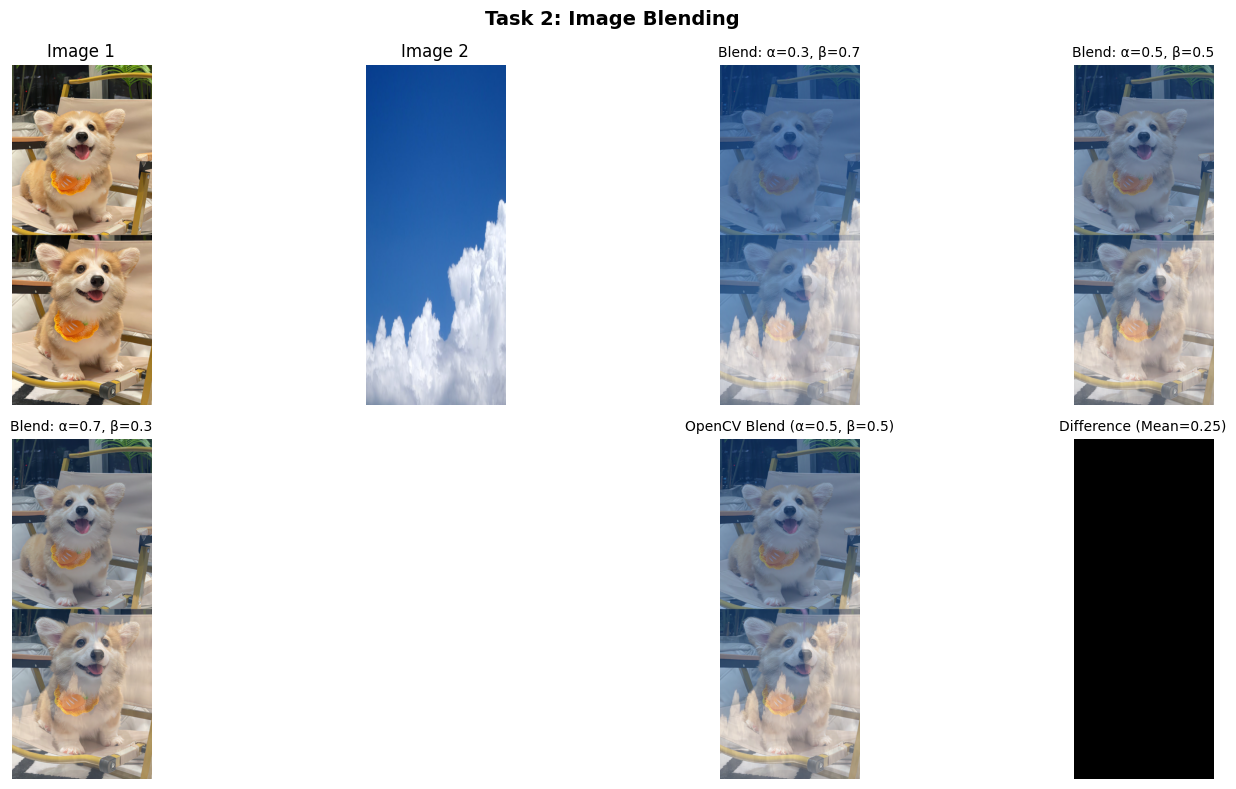

   Mean difference vs OpenCV: 0.2496


In [37]:
def task2_blending():

    # Nhập link ảnh thứ nhất
    print("\nURL or file img1:")
    source1 = input("→ ").strip()

    # Nhập link ảnh thứ hai
    print("\nURL or file img2:")
    source2 = input("→ ").strip()

    # Tải ảnh 1
    if source1.startswith('http://') or source1.startswith('https://'):
        img1_data, success1 = load_image_from_url(source1)
        name1 = "Image 1 from URL"
    else:
        img1_data, success1 = load_image_from_file(source1)
        name1 = os.path.basename(source1) if source1 else "Local Image 1"

    # Tải ảnh 2
    if source2.startswith('http://') or source2.startswith('https://'):
        img2_data, success2 = load_image_from_url(source2)
        name2 = "Image 2 from URL"
    else:
        img2_data, success2 = load_image_from_file(source2)
        name2 = os.path.basename(source2) if source2 else "Local Image 2"

    if not success1 or not success2:
        print("Cant upload one of img or both")
        return None

    print("\nUpload successful")
    if img1_data.shape[:2] != img2_data.shape[:2]:
        print(f"\nĐang resize ảnh 2 từ {img2_data.shape[:2]} về {img1_data.shape[:2]}...")
        img2_resized = cv2.resize(img2_data, (img1_data.shape[1], img1_data.shape[0]))
        print(f"  Sau resize: {img2_resized.shape}")
    else:
        img2_resized = img2_data.copy()

    # Lưu lại ảnh đã resize để dùng cho các phép so sánh
    img2_data = img2_resized


    # Các hệ số blending khác nhau
    alphas = [0.3, 0.5, 0.7]
    betas = [0.7, 0.5, 0.3]
    titles = [f'α={a}, β={b}' for a, b in zip(alphas, betas)]

    plt.figure(figsize=(15, 8))

    # Hiển thị 2 ảnh gốc
    plt.subplot(2, 4, 1)
    plt.imshow(img1_data)
    plt.title('Image 1', fontsize=12)
    plt.axis('off')

    plt.subplot(2, 4, 2)
    plt.imshow(img2_data)
    plt.title('Image 2', fontsize=12)
    plt.axis('off')

    # Hiển thị kết quả blending
    for i, (alpha, beta, title) in enumerate(zip(alphas, betas, titles)):
        blended = blend_images(img1_data, img2_data, alpha, beta, 0)

        plt.subplot(2, 4, i+3)
        plt.imshow(blended)
        plt.title(f'Blend: {title}', fontsize=10)
        plt.axis('off')

    # So sánh với OpenCV
    plt.subplot(2, 4, 7)
    cv_blend = cv2.addWeighted(img1_data, 0.5, img2_data, 0.5, 0)
    plt.imshow(cv_blend)
    plt.title('OpenCV Blend (α=0.5, β=0.5)', fontsize=10)
    plt.axis('off')

    # Difference
    my_blend = blend_images(img1_data, img2_data, 0.5, 0.5, 0)
    diff = np.abs(my_blend.astype(float) - cv_blend.astype(float))
    plt.subplot(2, 4, 8)
    plt.imshow(diff.astype(np.uint8), cmap='hot')
    plt.title(f'Difference (Mean={diff.mean():.2f})', fontsize=10)
    plt.axis('off')

    plt.suptitle('Task 2: Image Blending', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"   Mean difference vs OpenCV: {diff.mean():.4f}")

    return blended


# Chạy Task 2
if __name__ == "__main__":
    task2_blending()

#3. Thresholding (phân ngưỡng) - 6 loại
Lý thuyết các loại threshold

1. Binary:          dst = max_val if src > thresh else 0
2. Binary Inverted: dst = 0 if src > thresh else max_val
3. Truncated:       dst = thresh if src > thresh else src
4. To Zero:         dst = src if src > thresh else 0
5. To Zero Inverted: dst = 0 if src > thresh else src
6. Adaptive Gaussian: ngưỡng thay đổi theo từng vùng



In [26]:
# ============================================
# TASK 3: THRESHOLDING (PHÂN NGƯỠNG)
# ============================================

def my_threshold(img, thresh=127, max_val=255, type='binary'):
    """Các loại threshold cơ bản"""
    result = np.zeros_like(img)

    if type == 'binary':
        result[img > thresh] = max_val
    elif type == 'binary_inv':
        result[img <= thresh] = max_val
    elif type == 'trunc':
        result = img.copy()
        result[img > thresh] = thresh
    elif type == 'tozero':
        result = img.copy()
        result[img <= thresh] = 0
    elif type == 'tozero_inv':
        result = img.copy()
        result[img > thresh] = 0

    return result


In [11]:
def my_adaptive_threshold(img, block_size=11, C=2):
    """
    Adaptive Gaussian threshold
    - Tính ngưỡng cho từng pixel dựa trên vùng lân cận
    - Dùng Gaussian window để tính trọng số
    """
    h, w = img.shape
    result = np.zeros_like(img)

    # Padding để xử lý biên
    pad = block_size // 2
    padded = np.pad(img, pad, mode='reflect')

    # Tạo Gaussian kernel
    kernel = cv2.getGaussianKernel(block_size, -1)
    kernel_2d = np.outer(kernel, kernel)

    for i in range(h):
        for j in range(w):
            # Lấy vùng block_size x block_size
            region = padded[i:i+block_size, j:j+block_size]

            # Tính weighted mean
            weighted_mean = np.sum(region * kernel_2d) / np.sum(kernel_2d)

            # Áp dụng threshold
            thresh = weighted_mean - C
            result[i, j] = 255 if img[i, j] > thresh else 0

    return result


URL or file img:
→ https://i.pinimg.com/736x/c8/31/9c/c8319c47acce6ce97742750c4f995faa.jpg
Upload succesful from URL: https://i.pinimg.com/736x/c8/31/9c/c8319c47acce6ce...
Shape: (1280, 720, 3)

Converted to grayscale: (1280, 720)


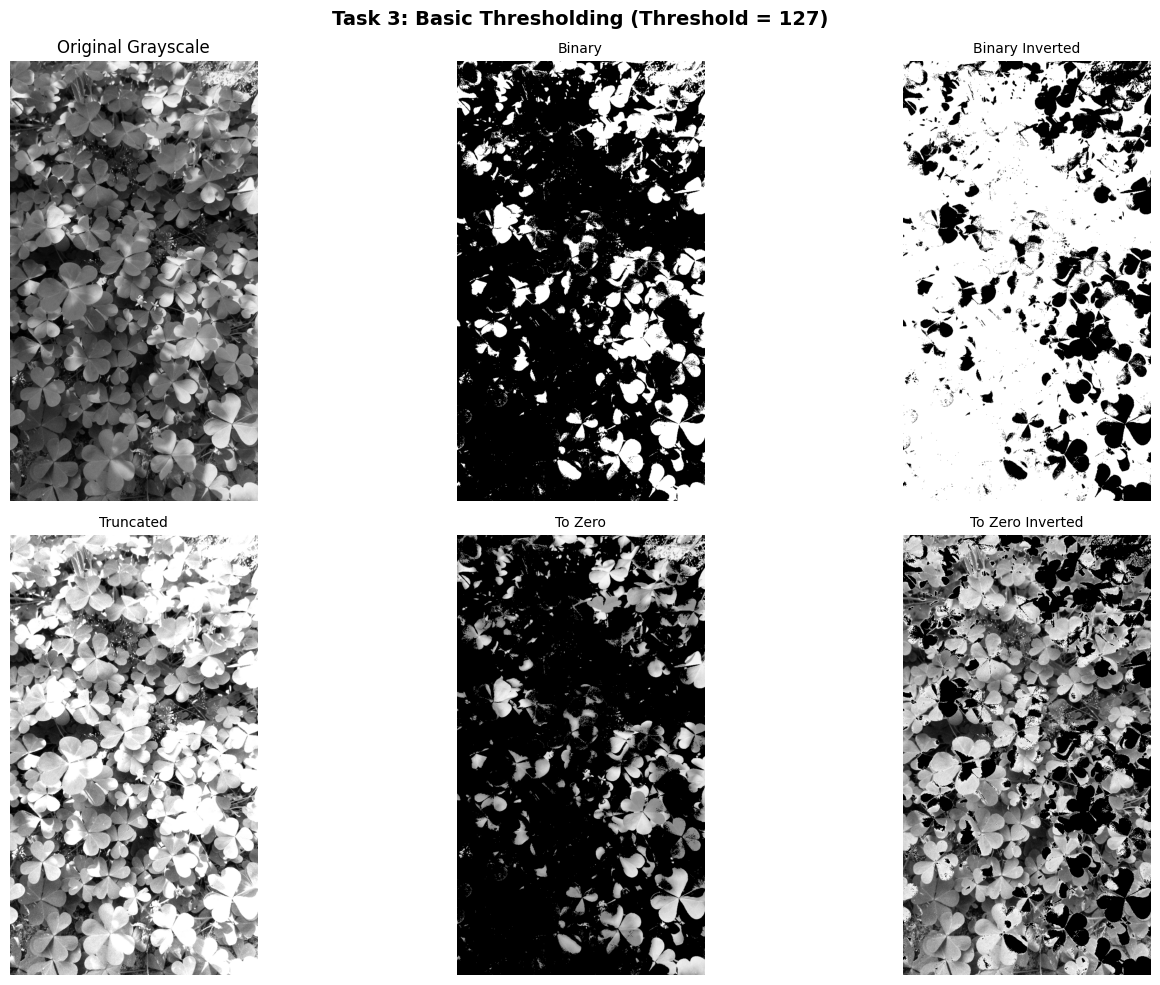


Adaptive Gaussian Threshold...


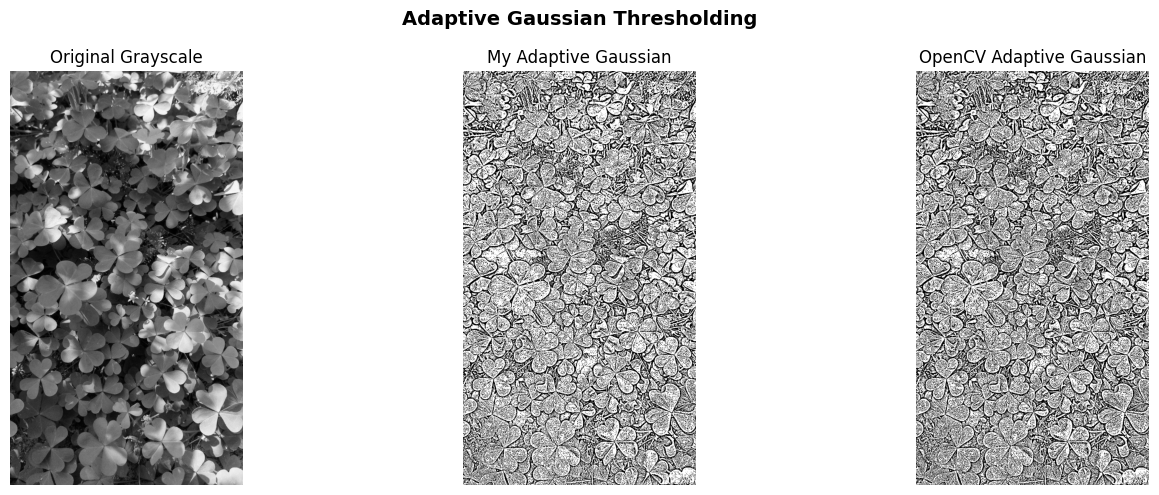

   Mean difference vs OpenCV (Adaptive): 7.6340


In [27]:
def task3_thresholding():

    # Nhập link ảnh
    print("\nURL or file img:")
    source = input("→ ").strip()

    # Tải ảnh
    if source.startswith('http://') or source.startswith('https://'):
        img_data, success = load_image_from_url(source)
        name = "Image from URL"
    else:
        img_data, success = load_image_from_file(source)
        name = os.path.basename(source) if source else "Local Image"

    if not success:
        print("Can't upload img")
        return None

    # Chuyển sang grayscale
    gray = cv2.cvtColor(img_data, cv2.COLOR_RGB2GRAY)
    print(f"\nConverted to grayscale: {gray.shape}")

    # Các loại threshold
    types = ['binary', 'binary_inv', 'trunc', 'tozero', 'tozero_inv']
    titles = ['Binary', 'Binary Inverted', 'Truncated', 'To Zero', 'To Zero Inverted']

    plt.figure(figsize=(15, 10))

    # Ảnh gốc
    plt.subplot(2, 3, 1)
    plt.imshow(gray, cmap='gray')
    plt.title('Original Grayscale', fontsize=12)
    plt.axis('off')

    # Các loại threshold
    for i, (t_type, title) in enumerate(zip(types, titles)):
        result = my_threshold(gray, thresh=127, max_val=255, type=t_type)
        plt.subplot(2, 3, i+2)
        plt.imshow(result, cmap='gray')
        plt.title(f'{title}', fontsize=10)
        plt.axis('off')

    plt.suptitle('Task 3: Basic Thresholding (Threshold = 127)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Adaptive Threshold riêng
    print("\nAdaptive Gaussian Threshold...")
    adaptive = my_adaptive_threshold(gray, block_size=11, C=2)

    # So sánh với OpenCV
    cv_adaptive = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY, 11, 2)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(gray, cmap='gray')
    plt.title('Original Grayscale', fontsize=12)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(adaptive, cmap='gray')
    plt.title('My Adaptive Gaussian', fontsize=12)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv_adaptive, cmap='gray')
    plt.title('OpenCV Adaptive Gaussian', fontsize=12)
    plt.axis('off')

    plt.suptitle('Adaptive Gaussian Thresholding', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Tính difference
    diff = np.abs(adaptive.astype(float) - cv_adaptive.astype(float))
    print(f"   Mean difference vs OpenCV (Adaptive): {diff.mean():.4f}")

    return adaptive


# Chạy Task 3
if __name__ == "__main__":
    task3_thresholding()

#4. PHẦN 4: BLURRING & SMOOTHING (LÀM MỜ)


In [30]:
def create_gaussian_kernel(size=5, sigma=1.0):
    """
    Tạo Gaussian kernel 2D
    """
    kernel = np.zeros((size, size))
    center = size // 2

    for i in range(size):
        for j in range(size):
            x, y = i - center, j - center
            kernel[i, j] = np.exp(-(x**2 + y**2) / (2 * sigma**2))

    # Chuẩn hóa
    kernel = kernel / np.sum(kernel)

    return kernel

In [31]:
def convolve2d(image, kernel):
    """
    Áp dụng kernel lên ảnh 2D
    """
    h, w = image.shape
    k_h, k_w = kernel.shape

    # Padding
    pad_h, pad_w = k_h // 2, k_w // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')

    result = np.zeros_like(image)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+k_h, j:j+k_w]
            result[i, j] = np.sum(region * kernel)

    return result

## Các loại blur

In [32]:
def apply_custom_filter(image, kernel):
    """Áp dụng filter tự định nghĩa"""
    return convolve2d(image, kernel)

def median_blur(image, kernel_size=3):
    """Median blur - lấy median của vùng lân cận"""
    h, w = image.shape
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')

    result = np.zeros_like(image)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            result[i, j] = np.median(region)

    return result

def gaussian_blur(image, kernel_size=5, sigma=1.0):
    """Gaussian blur với kernel tự tạo"""
    kernel = create_gaussian_kernel(kernel_size, sigma)
    return convolve2d(image, kernel)

def sobel_filter(image):
    """Sobel filter - phát hiện biên"""
    # Sobel X
    sobel_x = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]])

    # Sobel Y
    sobel_y = np.array([[-1, -2, -1],
                        [ 0,  0,  0],
                        [ 1,  2,  1]])

    gx = convolve2d(image, sobel_x)
    gy = convolve2d(image, sobel_y)

    # Độ lớn gradient
    magnitude = np.sqrt(gx**2 + gy**2)

    # Chuẩn hóa về [0, 255]
    magnitude = (magnitude / np.max(magnitude) * 255).astype(np.uint8)

    return magnitude


URL or file:
→ https://i.pinimg.com/736x/81/65/e6/8165e68bd065f6c1d32456586c08d119.jpg
Upload succesful from URL: https://i.pinimg.com/736x/81/65/e6/8165e68bd065f6c...
Shape: (736, 736, 3)

Converted to grayscale: (736, 736)


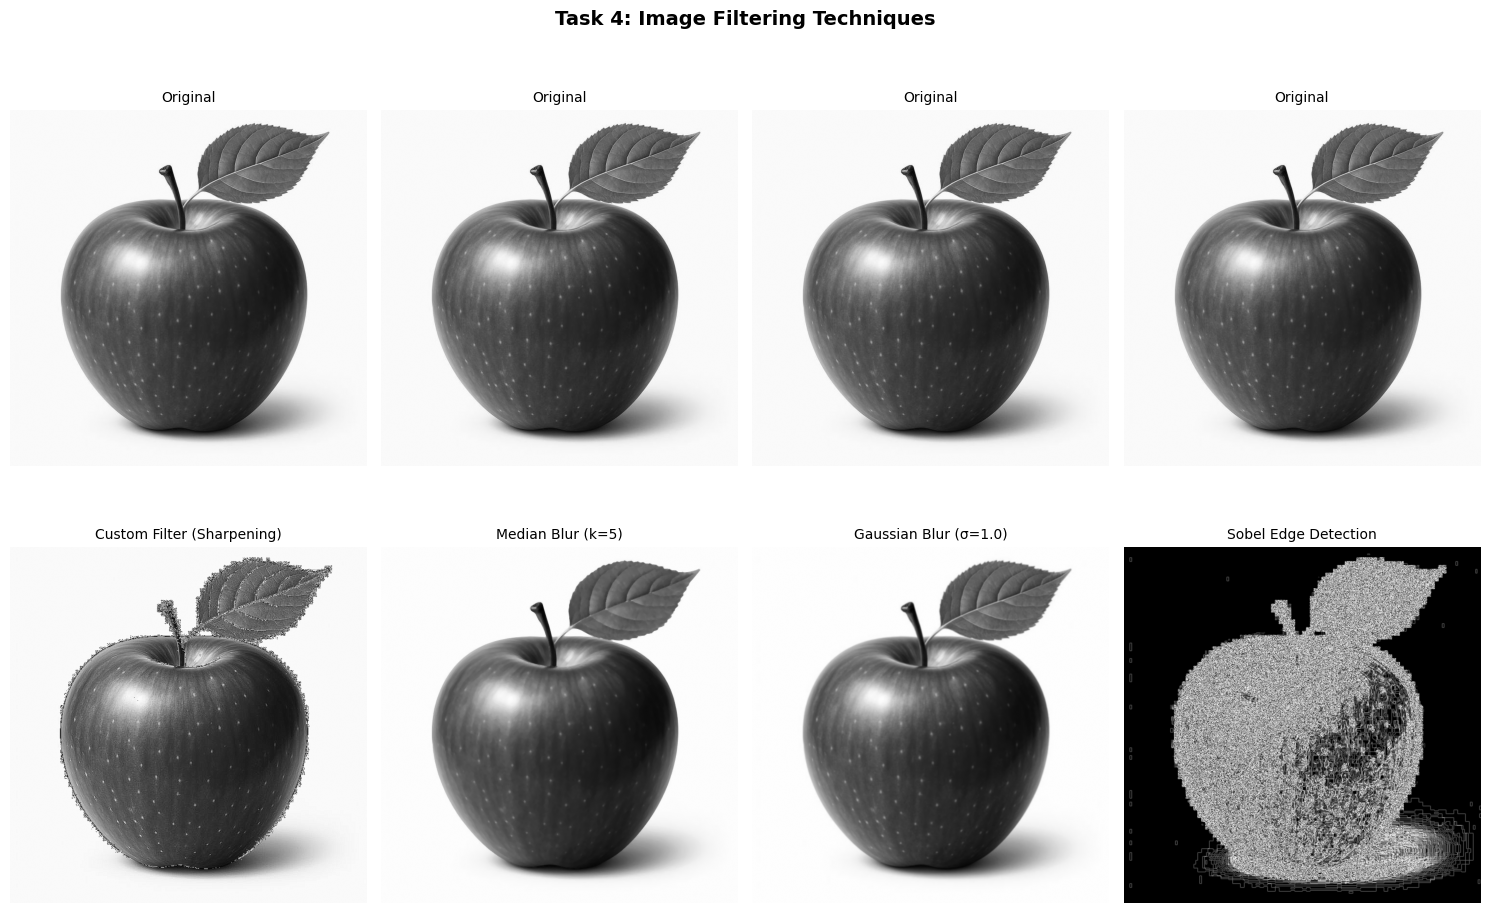

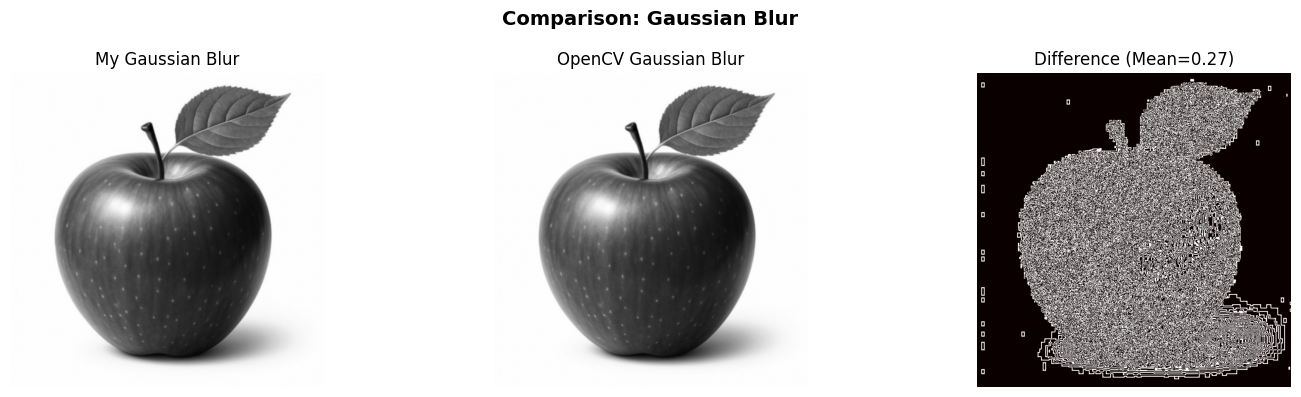

   Mean difference vs OpenCV (Gaussian): 0.2742


In [33]:
def task4_blurring():

    # Nhập link ảnh
    print("\nURL or file:")
    source = input("→ ").strip()

    # Tải ảnh
    if source.startswith('http://') or source.startswith('https://'):
        img_data, success = load_image_from_url(source)
        name = "Image from URL"
    else:
        img_data, success = load_image_from_file(source)
        name = os.path.basename(source) if source else "Local Image"

    if not success:
        print("Can't upload img")
        return None

    # Chuyển sang grayscale
    gray = cv2.cvtColor(img_data, cv2.COLOR_RGB2GRAY)
    print(f"\nConverted to grayscale: {gray.shape}")

    # Custom kernel (sharpening)
    custom_kernel = np.array([[0, -1, 0],
                              [-1, 5, -1],
                              [0, -1, 0]])

    my_custom = convolve2d(gray, custom_kernel)
    my_median = median_blur(gray, 5)
    my_gaussian = gaussian_blur(gray, 5, 1.0)
    my_sobel = sobel_filter(gray)

    results = [my_custom, my_median, my_gaussian, my_sobel]
    titles = ['Custom Filter (Sharpening)', 'Median Blur (k=5)',
              'Gaussian Blur (σ=1.0)', 'Sobel Edge Detection']

    plt.figure(figsize=(15, 10))

    for i, (res, title) in enumerate(zip(results, titles)):
        plt.subplot(2, 4, i+1)
        plt.imshow(gray, cmap='gray')
        plt.title('Original', fontsize=10)
        plt.axis('off')

        plt.subplot(2, 4, i+5)
        plt.imshow(res, cmap='gray')
        plt.title(f'{title}', fontsize=10)
        plt.axis('off')

    plt.suptitle('Task 4: Image Filtering Techniques', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # So sánh Gaussian Blur với OpenCV
    cv_gaussian = cv2.GaussianBlur(gray, (5, 5), 1.0)
    diff = np.abs(my_gaussian.astype(float) - cv_gaussian.astype(float))

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(my_gaussian, cmap='gray')
    plt.title('My Gaussian Blur', fontsize=12)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cv_gaussian, cmap='gray')
    plt.title('OpenCV Gaussian Blur', fontsize=12)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(diff, cmap='hot')
    plt.title(f'Difference (Mean={diff.mean():.2f})', fontsize=12)
    plt.axis('off')

    plt.suptitle('Comparison: Gaussian Blur', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"   Mean difference vs OpenCV (Gaussian): {diff.mean():.4f}")

    return my_gaussian


# Chạy Task 4
if __name__ == "__main__":
    task4_blurring()

#5. HISTOGRAM EQUALIZATION

## Tính histogram


In [17]:
def compute_histogram(image):
    """
    Tính histogram của ảnh grayscale
    Trả về mảng 256 phần tử - tần suất mỗi mức xám
    """
    histogram = np.zeros(256, dtype=int)
    h, w = image.shape

    for i in range(h):
        for j in range(w):
            pixel_value = image[i, j]
            histogram[pixel_value] += 1

    return histogram

## Tính CDF (Cumulative Distribution Function)

In [18]:
def compute_cdf(histogram):
    """
    Tính hàm phân phối tích lũy (CDF)
    """
    cdf = histogram.cumsum()

    # Chuẩn hóa về [0, 255]
    cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    cdf_normalized = cdf_normalized.astype(np.uint8)

    return cdf_normalized

## Histogram Equalization

In [19]:
def my_histogram_equalization(image):
    """
    Cân bằng histogram
    """
    # Tính histogram
    hist = compute_histogram(image)

    # Tính CDF
    cdf = hist.cumsum()

    # Chuẩn hóa CDF
    cdf_min = cdf[cdf > 0].min()
    cdf_max = cdf.max()

    # Áp dụng công thức equalization
    equalized = np.zeros_like(image)
    h, w = image.shape

    for i in range(h):
        for j in range(w):
            pixel = image[i, j]
            equalized[i, j] = ((cdf[pixel] - cdf_min) * 255 /
                              (cdf_max - cdf_min))

    return equalized.astype(np.uint8)


URL or file:
→ https://i.pinimg.com/1200x/5f/2b/94/5f2b9485bccaa403f33df516d389fc92.jpg
Upload succesful from URL: https://i.pinimg.com/1200x/5f/2b/94/5f2b9485bccaa4...
Shape: (2639, 1080, 3)

COnverted to grayscale: (2639, 1080)


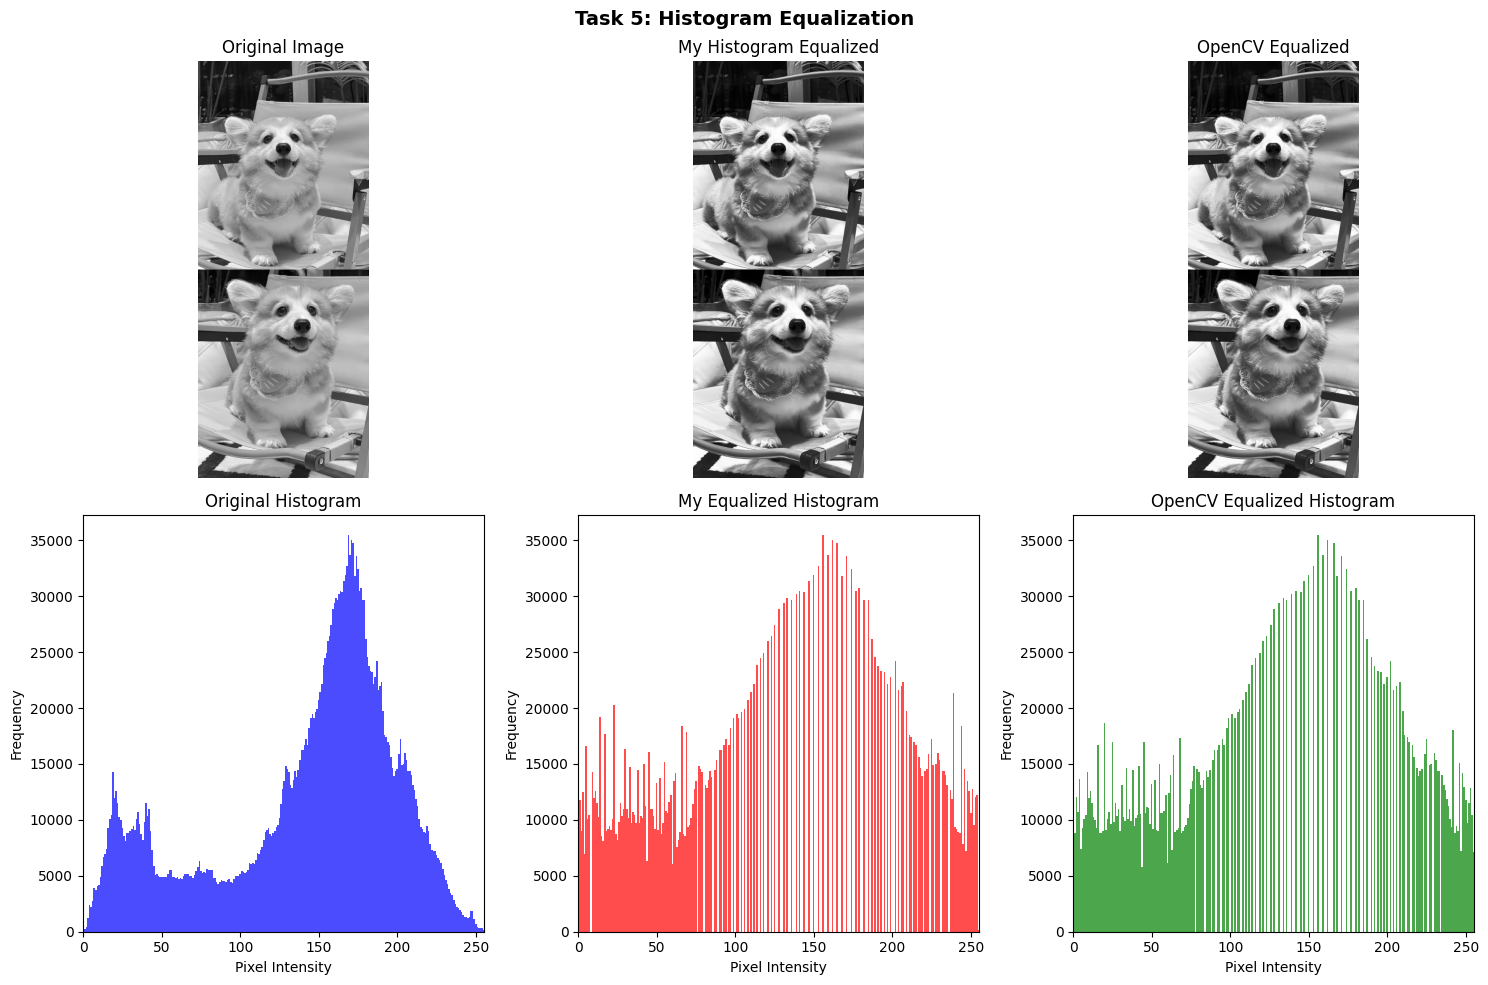

   Mean difference vs OpenCV: 0.4246
   Original - Min: 0, Max: 255, Mean: 142.43
   Equalized - Min: 0, Max: 255, Mean: 127.83


In [34]:
def task5_histogram():

    # Nhập link ảnh
    print("\nURL or file:")
    source = input("→ ").strip()

    # Tải ảnh
    if source.startswith('http://') or source.startswith('https://'):
        img_data, success = load_image_from_url(source)
        name = "Image from URL"
    else:
        img_data, success = load_image_from_file(source)
        name = os.path.basename(source) if source else "Local Image"

    if not success:
        print("Can't upload img")
        return None

    # Chuyển sang grayscale
    gray = cv2.cvtColor(img_data, cv2.COLOR_RGB2GRAY)
    print(f"\nCOnverted to grayscale: {gray.shape}")

    equalized = my_histogram_equalization(gray)

    # So sánh với OpenCV
    cv_equalized = cv2.equalizeHist(gray)

    # Tính histogram
    hist_orig = compute_histogram(gray)
    hist_eq = compute_histogram(equalized)
    hist_cv = compute_histogram(cv_equalized)

    plt.figure(figsize=(15, 10))

    # Ảnh
    plt.subplot(2, 3, 1)
    plt.imshow(gray, cmap='gray')
    plt.title('Original Image', fontsize=12)
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(equalized, cmap='gray')
    plt.title('My Histogram Equalized', fontsize=12)
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(cv_equalized, cmap='gray')
    plt.title('OpenCV Equalized', fontsize=12)
    plt.axis('off')

    # Histogram
    plt.subplot(2, 3, 4)
    plt.bar(range(256), hist_orig, width=1.0, color='blue', alpha=0.7)
    plt.title('Original Histogram', fontsize=12)
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.xlim([0, 255])

    plt.subplot(2, 3, 5)
    plt.bar(range(256), hist_eq, width=1.0, color='red', alpha=0.7)
    plt.title('My Equalized Histogram', fontsize=12)
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.xlim([0, 255])

    plt.subplot(2, 3, 6)
    plt.bar(range(256), hist_cv, width=1.0, color='green', alpha=0.7)
    plt.title('OpenCV Equalized Histogram', fontsize=12)
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.xlim([0, 255])

    plt.suptitle('Task 5: Histogram Equalization', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Tính difference
    diff = np.abs(equalized.astype(float) - cv_equalized.astype(float))

    print(f"   Mean difference vs OpenCV: {diff.mean():.4f}")
    print(f"   Original - Min: {gray.min()}, Max: {gray.max()}, Mean: {gray.mean():.2f}")
    print(f"   Equalized - Min: {equalized.min()}, Max: {equalized.max()}, Mean: {equalized.mean():.2f}")

    return equalized


# Chạy Task 5
if __name__ == "__main__":
    task5_histogram()